## Which world regions have the most motorcycle models in the dataset?

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [2]:
df = pd.read_csv("EX4_WJ_geopy.csv")
df.head(5)

,Country of Origin,1994,1998,2000,2002,2003,2005,2006,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,latitude,longitude
0,Austria,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,9,47.593970,14.124560
1,Canada,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,61.066692,-107.991707
2,China,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,31,35.000074,104.999927
3,Denmark,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,55.670249,10.333328
4,France,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,46.603354,1.888334


In [3]:
geometry = gpd.points_from_xy(
    df["longitude"],
    df["latitude"]
)

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf.head()

,Country of Origin,1994,1998,2000,2002,2003,2005,2006,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,latitude,longitude,geometry
0,Austria,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,5,9,47.593970,14.124560,POINT (14.12456 47.59397)
1,Canada,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,61.066692,-107.991707,POINT (-107.99171 61.06669)
2,China,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,13,31,35.000074,104.999927,POINT (104.99993 35.00007)
3,Denmark,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,55.670249,10.333328,POINT (10.33333 55.67025)
4,France,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,8,46.603354,1.888334,POINT (1.88833 46.60335)


In [4]:
regions = gpd.read_file("Regions/worldregions.shp")

regions.head()

,Region,COUNT_Regi,Shape_Leng,Shape_Area,geometry
0,Austral,2,5.693303e+07,1.067385e+13,"MULTIPOLYGON (((17686682.846 -7306054.029, 176..."
1,Central Asia,1,1.937302e+07,8.710063e+12,"POLYGON ((6000747.867 4488125.097, 5975331.286..."
2,East Asia,1,5.531699e+07,1.926352e+13,"MULTIPOLYGON (((12324829.954 2281193.109, 1233..."
3,Europe,4,1.726394e+08,1.856801e+13,"MULTIPOLYGON (((2654806.574 4235181.553, 26684..."
4,Middle America,2,3.706315e+07,3.184980e+12,"MULTIPOLYGON (((-9092406.12 824784.893, -90891..."


In [5]:
regions = regions.to_crs("EPSG:4326")

In [6]:
joined_gdf = gpd.sjoin(
    gdf,
    regions,
    how="inner",
    predicate="intersects"
)

joined_gdf.head()

,Country of Origin,1994,1998,2000,2002,2003,2005,2006,2014,2015,...,2022,2023,latitude,longitude,geometry,index_right,Region,COUNT_Regi,Shape_Leng,Shape_Area
0,Austria,0,0,0,0,0,0,0,0,0,...,5,9,47.593970,14.124560,POINT (14.12456 47.59397),3,Europe,4,1.726394e+08,1.856801e+13
1,Canada,0,0,0,0,0,0,0,0,0,...,0,3,61.066692,-107.991707,POINT (-107.99171 61.06669),6,North America,1,5.638022e+08,1.082242e+14
2,China,0,0,0,0,0,0,0,0,0,...,13,31,35.000074,104.999927,POINT (104.99993 35.00007),2,East Asia,1,5.531699e+07,1.926352e+13
4,France,0,0,0,0,0,0,0,0,0,...,0,8,46.603354,1.888334,POINT (1.88833 46.60335),3,Europe,4,1.726394e+08,1.856801e+13
5,Germany,0,0,0,0,0,0,0,0,0,...,0,8,51.163818,10.447831,POINT (10.44783 51.16382),3,Europe,4,1.726394e+08,1.856801e+13


In [7]:
region_summary = joined_gdf.groupby("Region").size().reset_index(name="motorcycle_count")

region_summary

,Region,motorcycle_count
0,East Asia,4
1,Europe,8
2,North America,3
3,South Asia,1


In [8]:
regions_summary = regions.merge(
    region_summary,
    on="Region",
    how="left"
)

regions_summary["motorcycle_count"] = regions_summary["motorcycle_count"].fillna(0)

regions_summary.head()

,Region,COUNT_Regi,Shape_Leng,Shape_Area,geometry,motorcycle_count
0,Austral,2,5.693303e+07,1.067385e+13,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",0.0
1,Central Asia,1,1.937302e+07,8.710063e+12,"POLYGON ((53.90564 37.35086, 53.67731 37.33536...",0.0
2,East Asia,1,5.531699e+07,1.926352e+13,"MULTIPOLYGON (((110.71583 20.06889, 110.77859 ...",4.0
3,Europe,4,1.726394e+08,1.856801e+13,"MULTIPOLYGON (((23.84853 35.52298, 23.97138 35...",8.0
4,Middle America,2,3.706315e+07,3.184980e+12,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7...",0.0


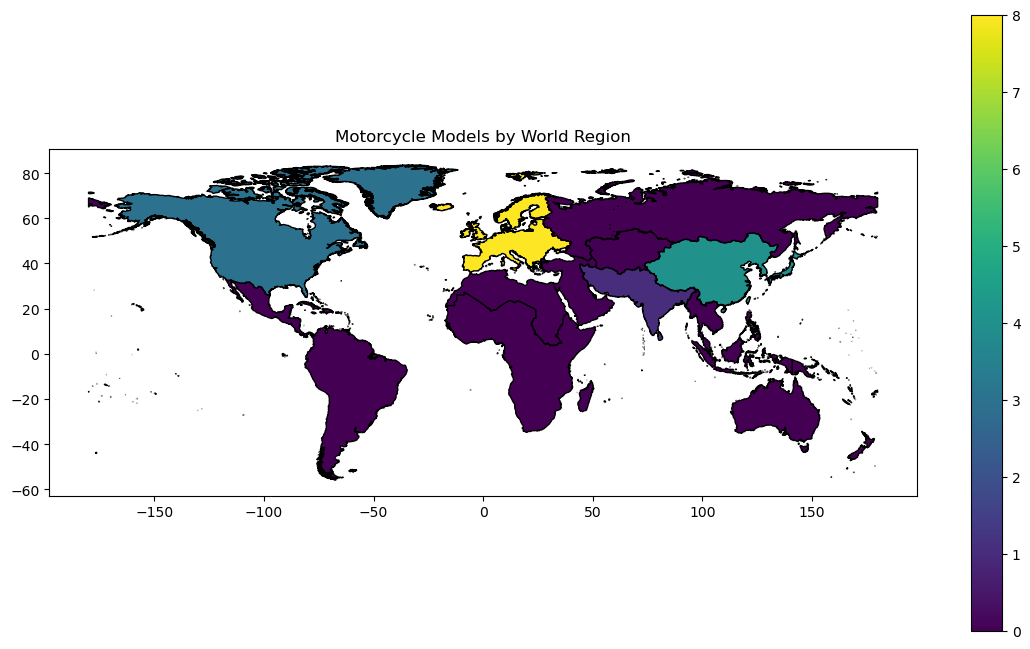

In [9]:
ax = regions_summary.plot(
    column="motorcycle_count",
    legend=True,
    figsize=(14, 8),
    edgecolor="black"
)

plt.title("Motorcycle Models by World Region")
plt.show()

In [10]:
region_summary.to_csv("motorcycle_region_summary_WJ.csv", index=False)

In [11]:
regions_summary.to_file("motorcycle_regions_summary.geojson", driver="GeoJSON")